# 02 — IEEE 13-node unbalanced feeder

**Goal:** run the bundled IEEE13 feeder, inspect the phase-specific bus state, then verify the saved evidence.

**Teaching focus:** bus 671; phases 1/2/3 are A/B/C. Keep the phases separate — imbalance is the point of this feeder.

**Prediction:** the three phase voltages at bus 671 should differ.

Run the numbered cells in order. The direct OpenDSS section at the end is optional.

In [1]:
#@title 1. Setup — run once
import contextlib, io, urllib.request, hashlib
_HELPER_URL = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/75b4f394aa096a604123e6e1739d2581e8ef9476/public/notebooks/_lesson.py"
_HELPER_SHA256 = "8618face0c62b85127ffadc7b662bc177ab3ba5a36e32a09ee5223f562e02ba2"
try:
    _blob = urllib.request.urlopen(_HELPER_URL, timeout=60).read()
    _digest = hashlib.sha256(_blob).hexdigest()
    if _digest != _HELPER_SHA256:
        raise ValueError(f"lesson helper hash mismatch (expected {_HELPER_SHA256}, got {_digest})")
    _helper_output = io.StringIO()
    with contextlib.redirect_stdout(_helper_output):
        exec(compile(_blob, "lesson helper", "exec"))
except Exception as exc:
    print("What happened: the pinned lesson helper could not be downloaded or verified.")
    print(f"Details: {type(exc).__name__}: {exc}")
    print("Next: check network access to the public helper URL, then rerun this setup cell.")
    raise SystemExit(1) from None
for _line in _helper_output.getvalue().splitlines():
    if "lesson helpers ready" not in _line.lower():
        print(_line)
print("Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.")

# Compatibility renderer for the currently pinned public wheel; newer wheels use cept.public_notebook.
def display_run_compat(run_dir):
    import html as _html
    from IPython.display import HTML, display
    result = read(Path(run_dir) / 'results.json')
    sld = result.get('sld') or result.get('sld_after') or {}
    nodes, edges = sld.get('nodes') or [], sld.get('edges') or []
    if not nodes:
        display(HTML('<p><strong>CEPT result:</strong> this run does not carry an SLD.</p>'))
        return
    xs, ys = [float(n['x']) for n in nodes], [float(n['y']) for n in nodes]
    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    dx, dy = max(x1-x0, 1.0), max(y1-y0, 1.0)
    def xy(node):
        return 65 + (float(node['x'])-x0)/dx*870, 45 + (float(node['y'])-y0)/dy*420
    pos = {str(n['id']): xy(n) for n in nodes}
    line_svg = []
    for edge in edges:
        if str(edge.get('src')) in pos and str(edge.get('dst')) in pos:
            a, b = pos[str(edge['src'])], pos[str(edge['dst'])]
            dash = ' stroke-dasharray=\"8 6\"' if edge.get('status') == 'open' else ''
            edge_label = _html.escape(str(edge.get('id', 'branch')))
            line_svg.append(f'<line x1=\"{a[0]:.1f}\" y1=\"{a[1]:.1f}\" x2=\"{b[0]:.1f}\" y2=\"{b[1]:.1f}\" stroke=\"#7a879a\" stroke-width=\"3\"{dash}><title>{edge_label}</title></line>')
    vmin, vmax = float(sld.get('v_min_pu', .95)), float(sld.get('v_max_pu', 1.05))
    bus_svg, rows = [], []
    for node in nodes:
        volts = {int(k): float(v) for k, v in (node.get('v_pu') or {}).items()}
        angles = {int(k): float(v) for k, v in (node.get('angle_deg') or {}).items()}
        values = list(volts.values())
        low, high = any(v < vmin for v in values), any(v > vmax for v in values)
        status = 'NO DATA' if not values else 'OUT' if low and high else 'UNDER' if low else 'OVER' if high else 'OK'
        fill = {'OK':'#e8f5ec','UNDER':'#fff3d9','OVER':'#ffe7e1','OUT':'#f7e7ff','NO DATA':'#eef1f5'}[status]
        stroke = {'OK':'#2f7d4a','UNDER':'#a46700','OVER':'#b8432e','OUT':'#8147a6','NO DATA':'#7b8796'}[status]
        x, y = pos[str(node['id'])]
        phase = lambda p: '—' if p not in volts else f'{volts[p]:.4f} pu' + (f' @ {angles[p]:.2f}°' if p in angles else '')
        tip = _html.escape('Bus '+str(node['id'])+'\nStatus: '+status+'\n'+'\n'.join(f'{label}: {phase(p)}' for p,label in [(1,'A'),(2,'B'),(3,'C')] if p in volts))
        label = _html.escape(str(node['id']))
        bus_svg.append(f'<g tabindex=\"0\"><title>{tip}</title><rect x=\"{x-31:.1f}\" y=\"{y-11:.1f}\" width=\"62\" height=\"22\" rx=\"5\" fill=\"{fill}\" stroke=\"{stroke}\" stroke-width=\"2\"/><text x=\"{x:.1f}\" y=\"{y+4:.1f}\" text-anchor=\"middle\" font-size=\"12\" font-weight=\"700\">{label}</text></g>')
        rows.append('<tr><th>'+label+'</th><td>'+phase(1)+'</td><td>'+phase(2)+'</td><td>'+phase(3)+'</td><td><strong>'+status+'</strong></td></tr>')
    display(HTML('<div style=\"font-family:system-ui,sans-serif\"><h3>Interactive CEPT SLD</h3><p style=\"color:#657187\">Hover or focus a bus for solver-returned values.</p><div style=\"overflow:hidden;border:1px solid #d9dee8;border-radius:10px\"><svg viewBox=\"0 0 1000 510\" style=\"width:100%;height:auto;display:block\">'+''.join(line_svg)+''.join(bus_svg)+'</svg></div><div style=\"overflow-x:auto;margin-top:10px\"><table style=\"border-collapse:collapse;width:100%;min-width:650px\"><thead><tr><th>Bus</th><th>Phase A</th><th>Phase B</th><th>Phase C</th><th>Status</th></tr></thead><tbody>'+''.join(rows)+'</tbody></table></div></div>'))


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version
cept-power-studio 0.2.0.dev0
Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


In [2]:
#@title 2. Inputs — feeder and bus to inspect
RUN_DIR = WORKSPACE / "runs" / "02-ieee13-unbalanced"
BUS_TO_INSPECT = "671"
table(
    ["declared input", "value", "unit"],
    [
        ("network", "IEEE 13-node feeder", "text"),
        ("bus to inspect", BUS_TO_INSPECT, "bus"),
        ("phases", "A / B / C", "text"),
    ],
)

| declared input | value | unit |
| --- | --- | --- |
| network | IEEE 13-node feeder | text |
| bus to inspect | 671 | bus |
| phases | A / B / C | text |


In [3]:
# 3. Run study — same CEPT CLI as a normal terminal
!cept study demo unbalanced-load-flow \
    --network ieee13 \
    --out runs/02-ieee13-unbalanced \
    --force \
    --format text

CEPT study result: FINISHED
----------------------------
Result             Finished the unbalanced load flow (IEEE 13-node) and saved the evidence
Saved run          runs\02-ieee13-unbalanced
Case fingerprint   4716c9c07f02 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept study verify runs\02-ieee13-unbalanced --format text


In [4]:
#@title 4. Explore — SLD and bus status
RUN_DIR = WORKSPACE / "runs" / "02-ieee13-unbalanced"
try:
    from cept.public_notebook import display_run
except ModuleNotFoundError:
    display_run = display_run_compat
display_run(RUN_DIR)

Bus,Phase A,Phase B,Phase C,Status
611,—,—,0.9608 pu @ 115.74°,OK
632,1.0143 pu @ -2.53°,1.0289 pu @ -121.76°,1.0042 pu @ 117.77°,OK
633,1.0113 pu @ -2.59°,1.0270 pu @ -121.81°,1.0015 pu @ 117.76°,OK
634,0.9872 pu @ -3.28°,1.0084 pu @ -122.27°,0.9825 pu @ 117.27°,OK
645,—,1.0197 pu @ -121.94°,1.0023 pu @ 117.79°,OK
646,—,1.0180 pu @ -122.02°,1.0002 pu @ 117.84°,OK
650,0.9999 pu @ -0.01°,1.0000 pu @ -120.01°,0.9999 pu @ 119.99°,OK
652,0.9753 pu @ -5.32°,—,—,OK
670,1.0040 pu @ -3.46°,1.0319 pu @ -121.97°,0.9898 pu @ 117.10°,OK
671,0.9828 pu @ -5.37°,1.0403 pu @ -122.39°,0.9649 pu @ 115.99°,OK


In [5]:
#@title 5. Engineering result — bus 671 by phase
results = read(RUN_DIR / "results.json")
bus_rows = [
    row for row in results["load_flow"]["bus_voltages"]
    if row["bus"].lower() == BUS_TO_INSPECT.lower()
]
table(
    ["bus", "phase", "voltage", "angle", "unit"],
    [
        (row["bus"], row["phase"], row["v_pu"], row["v_angle_deg"], "pu / deg")
        for row in bus_rows
    ],
)
assert {row["phase"] for row in bus_rows} == {1, 2, 3}

| bus | phase | voltage | angle | unit |
| --- | --- | --- | --- | --- |
| 671 | 1 | 0.982797 | -5.3738 | pu / deg |
| 671 | 2 | 1.040275 | -122.3902 | pu / deg |
| 671 | 3 | 0.964889 | 115.9871 | pu / deg |


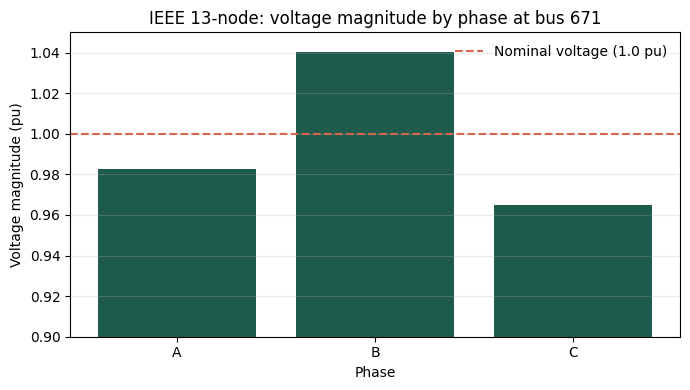

In [6]:
#@title 6. Plot — phase voltages at bus 671
import matplotlib.pyplot as plt

phase_values = {row["phase"]: float(row["v_pu"]) for row in bus_rows}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["A", "B", "C"], [phase_values[phase] for phase in (1, 2, 3)], color="#1f5b4d")
ax.axhline(1.0, color="#d5654e", linestyle="--", linewidth=1.5, label="Nominal voltage (1.0 pu)")
ax.set_title("IEEE 13-node: voltage magnitude by phase at bus 671")
ax.set_xlabel("Phase")
ax.set_ylabel("Voltage magnitude (pu)")
ax.set_ylim(0.90, 1.05)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)


In [7]:
# 6. Verify — check this exact saved run
!cept study verify runs/02-ieee13-unbalanced --format text

CEPT study check: PASSED
----------------------------
Study              Unbalanced load flow (OpenDSS)
Case fingerprint   4716c9c07f02 (matches the case you ran)

Checked   3 groups, 14 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (3 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept study verify . --format json


## 7. Interpret

Bus 671 is unbalanced, so the three phase values should be read individually rather than replaced by one balanced number.

**What this proves:** CEPT preserved and returned phase-specific solver values for the bundled feeder.

**What this does not prove:** independent validation of a real distribution network.

**Try next:** choose another named bus and inspect its phase values without averaging the phases together.

## Optional — direct OpenDSS comparison

The cells below load the same bundled feeder directly in OpenDSS and compare bus 671 phase values with the persisted CEPT result. They are optional details, not a second product workflow.

In [8]:
#@title Under the hood - direct OpenDSS solve (optional)
MASTER_DSS = ieee13_master()
import opendssdirect as dss

dss.Basic.ClearAll()
dss.Basic.DataPath(str(MASTER_DSS.parent))
dss.Text.Command(f'Redirect "{MASTER_DSS}"')
dss.Text.Command('CalcVoltageBases')
dss.Text.Command('Solve')
assert dss.Solution.Converged()
os.chdir(WORKSPACE)
print("Direct OpenDSS solve finished: the IEEE 13-node feeder converged.")


Direct OpenDSS solve finished: the IEEE 13-node feeder converged.


In [9]:
#@title Under the hood — direct OpenDSS readback (optional)
dss.Circuit.SetActiveBus(BUS_TO_INSPECT)
direct_values = dss.Bus.puVmagAngle()
direct_by_phase = {phase: float(direct_values[2 * (phase - 1)]) for phase in (1, 2, 3)}
table(['source', 'bus', 'phase', 'voltage magnitude', 'unit'], [('direct OpenDSS', BUS_TO_INSPECT, phase, value, 'pu') for phase, value in direct_by_phase.items()])
assert all(value > 0 for value in direct_by_phase.values())

| source | bus | phase | voltage magnitude | unit |
| --- | --- | --- | --- | --- |
| direct OpenDSS | 671 | 1 | 0.9827953877537872 | pu |
| direct OpenDSS | 671 | 2 | 1.040273943965177 | pu |
| direct OpenDSS | 671 | 3 | 0.9648999396286697 | pu |


In [10]:
#@title Compare solver outputs (optional details)
RUN_DIR = WORKSPACE / "runs" / "02-ieee13-unbalanced"
results = read(RUN_DIR / "results.json")
verify_summary = read(RUN_DIR / "public-verification.json")
cept_rows = [row for row in results["load_flow"]["bus_voltages"] if row["bus"].lower() == BUS_TO_INSPECT.lower()]
cept_by_phase = {row["phase"]: row["v_pu"] for row in cept_rows}
table(
    ["phase", "direct OpenDSS pu", "CEPT pu", "|difference| pu"],
    [(phase, direct_by_phase[phase], cept_by_phase[phase], abs(direct_by_phase[phase] - cept_by_phase[phase])) for phase in (1, 2, 3)],
)
max_abs_diff_pu = max(abs(direct_by_phase[phase] - cept_by_phase[phase]) for phase in (1, 2, 3))
print()
print("Direct OpenDSS and CEPT agree on all 3 phases")
print("--------------------------------------------")
print(f"Result        {'PASSED' if verify_summary['passed'] else 'Needs attention'}")
print(f"Largest phase difference: {max_abs_diff_pu:.2e} per unit (limit 1e-4 per unit)")
print("A small difference is rounding, not a different answer.")
assert verify_summary["status"] == "PASS"
assert verify_summary["passed"] is True
assert set(cept_by_phase) == {1, 2, 3}
assert max_abs_diff_pu < 1e-4


| phase | direct OpenDSS pu | CEPT pu | |difference| pu |
| --- | --- | --- | --- |
| 1 | 0.9827953877537872 | 0.982797 | 1.6122462128675963e-06 |
| 2 | 1.040273943965177 | 1.040275 | 1.0560348231436478e-06 |
| 3 | 0.9648999396286697 | 0.964889 | 1.0939628669714985e-05 |

Direct OpenDSS and CEPT agree on all 3 phases
--------------------------------------------
Result        PASSED
Largest phase difference: 1.09e-05 per unit (limit 1e-4 per unit)
A small difference is rounding, not a different answer.
